In [281]:
import pandas as pd

file = open("/home/sawini-jana/hep/pythia8316/coding/observables.csv", "r", newline='')
df = pd.read_csv(file)

print(df['phi1'][0:5] + 1)
print(df.loc[10:12]['phi2'])

top = df[df.label==1][['phi1', 'phi2', 'phi3', 'phi4']].values
qcd = df[df.label==0][['phi1', 'phi2', 'phi3', 'phi4']].values
print(top)

0    1.123281
1    1.058460
2    1.042987
3    1.090834
4    1.078538
Name: phi1, dtype: float64
10    0.260957
11    0.283368
12    0.255451
Name: phi2, dtype: float64
[[0.123281   0.194045   0.223945   0.0144122 ]
 [0.0584601  0.150769   0.253806   0.0165512 ]
 [0.0429873  0.346099   0.152688   0.00440284]
 ...
 [0.0659491  0.239139   0.260959   0.0222304 ]
 [0.0238051  0.272196   0.125912   0.00210231]
 [0.0297438  0.249544   0.232666   0.0162619 ]]


In [296]:
print(len(top)+len(qcd))

2170


In [282]:
import numpy as np

In [283]:
number = int(len(top) * 10)
half = int(len(qcd)/2)
qcd = qcd[half:half+number]
ref = np.vstack([top, qcd])

#defining the task direction

mu_top = np.mean(top, axis=0)
mu_qcd = np.mean(qcd, axis=0)

v = mu_top - mu_qcd
v = v / np.linalg.norm(v) #normalizing factor
print(v)

[-0.53495376  0.65941367  0.52292234  0.07450051]


In [284]:
def KL_exact(obs, v, t): #(N x 4) #(4 x 1) #1
    
    obs_mean = np.mean(obs, axis= 0) #(4 x 1)
    t1 = - t*v @ obs_mean #scalar 
    t2 = np.log(np.mean(np.exp(np.matmul(obs, t*v))))
    
    return t2 + t1

In [285]:
def quadratic(obs, v, t):

    obs_mean = np.mean(obs, axis=0) #[4 X 1]
    I = np.zeros((4,4))
    for i in range(len(I)):
        for j in range(len(I)):
            I[i][j] = (obs[:,i] - obs_mean[i]) @ (obs[:,j] - obs_mean[j]) 
            I[i][j] /= len(obs) #normalization
    direction = t*v #(4 x 1)

    return (direction @ I @ direction)/2

In [286]:
def cubic(obs, v, t):
    obs_mean = np.mean(obs, axis=0) #[4 X 1]
    I = np.zeros((4,4,4))
    for i in range(len(I)):
        for j in range(len(I)):
            for k in range(len(I)):

                a = obs[:, i] - obs_mean[i]
                b = obs[:, j] - obs_mean[j]
                c = obs[:, k] - obs_mean[k]
                I[i][j][k] = np.einsum('m,m,m->', a, b, c)
                I[i][j][k] /= len(obs)

    direction = t*v #(4 x 1)
    return (np.einsum('i, j, k, ijk -> ', direction, direction, direction, I))/6

In [287]:
print(ref[:,1] - np.mean(ref, axis=0)[1])
print(ref[:,2] - np.mean(ref, axis=0)[2])
a = ref[:,2] - np.mean(ref, axis=0)[2]
b = ref[:,1] - np.mean(ref, axis=0)[1]
a @ b

[-0.03330107 -0.07657707  0.11875293 ...  0.01365393 -0.09469807
 -0.13530497]
[ 0.04219869  0.07205969 -0.02905831 ...  0.05327269  0.04437769
 -0.04099431]


np.float64(1.6414644748092193)

### Table 1

In [288]:
print(" t\texact KL\tquadratic\tquadratic+cubic\t error reduction ")
e_list = []
q_list = []
c_list = []
t_list = []
for i in range(1,13):
    t = round(0.05*i,2)
    t_list.append(t)
    exact= KL_exact(ref, v, t)
    quad = quadratic(ref, v, t)
    cub = quadratic(ref, v, t) + cubic(ref, v, t)

    error_q = np.abs(quad - exact)
    error_c = np.abs(cub - exact)
    error_red = error_q/error_c 

    #Table 1
    print(f"{t:.2f}    {exact*1e3:.6f}\t{quad*1e3:.6f}\t   {cub*1e3:.6f}\t    {error_red:.1f}")
    e_list.append(exact) 
    q_list.append(error_q)
    c_list.append(error_c)
      

 t	exact KL	quadratic	quadratic+cubic	 error reduction 
0.05    0.005087	0.005092	   0.005087	    1178.7
0.10    0.020328	0.020367	   0.020328	    588.9
0.15    0.045695	0.045827	   0.045695	    392.3
0.20    0.081158	0.081470	   0.081157	    294.0
0.25    0.126689	0.127297	   0.126686	    235.0
0.30    0.182257	0.183307	   0.182252	    195.7
0.35    0.247836	0.249502	   0.247826	    167.6
0.40    0.323395	0.325880	   0.323378	    146.5
0.45    0.408907	0.412441	   0.408880	    130.2
0.50    0.504343	0.509187	   0.504301	    117.1
0.55    0.609674	0.616116	   0.609614	    106.3
0.60    0.724873	0.733229	   0.724787	    97.4


### Figure 2

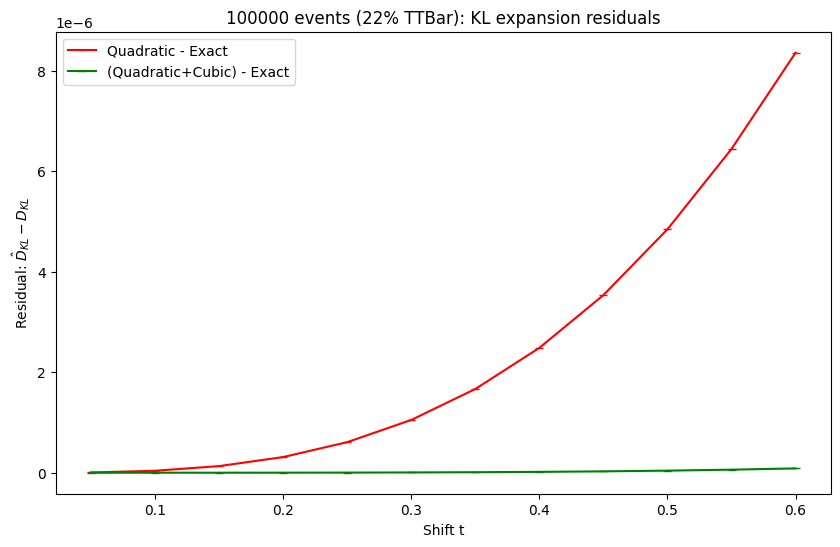

In [289]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(t_list, q_list, label="Quadratic - Exact", marker="_", color="red")
plt.plot(t_list, c_list, label="(Quadratic+Cubic) - Exact", marker="_", color="green")
plt.xlabel("Shift t")
plt.ylabel(r"Residual: $\hat{D}_{KL} - D_{KL}$")
plt.title("100000 events (22% TTBar): KL expansion residuals")
plt.legend()
plt.show()

In [290]:

obs_mean = np.mean(ref, axis=0) #[4 X 1]
centered = ref - obs_mean
I2_raw = centered.T @ centered / len(ref)
std = np.sqrt(np.diag(I2_raw))
ref_std = centered / std

def pairwise(Navy_bars, ref):

    I2 = np.zeros((4,4))
    for i in range(len(I2)):
        for j in range(len(I2)):
            I2[i][j] = ref[:,i] @ ref[:,j] / len(ref)
        Navy_bars[i] = np.sum(np.abs(I2[i])) - abs(I2[i][i])

    return I2 , Navy_bars

def hypergraph(Orange_bars, ref):

    I3 = np.zeros((4,4,4))
    for i in range(len(I3)):
        for j in range(i+1,len(I3)):
            for k in range(j+1,len(I3)):
                a = ref[:, i] 
                b = ref[:, j] 
                c = ref[:, k]
                I3[i][j][k] = np.einsum('m,m,m->', a, b, c)
                I3[i][j][k] /= len(ref)

                val = abs(I3[i][j][k])
                Orange_bars[i] += val
                Orange_bars[j] += val
                Orange_bars[k] += val
    
    return I3 , Orange_bars

Navy_bars = np.zeros(4)
I2, Pair = pairwise(Navy_bars, ref_std)
Orange_bars = np.zeros(4)
I3 , Hyper = hypergraph(Orange_bars, ref_std)
print(Pair)
print(Hyper)    

[0.63937638 0.74517639 1.32131264 1.2244056 ]
[0.4174035  0.55449092 0.55010457 0.45618185]


### Table 2

In [297]:
def Whitening(obs, I):
    
    #using EigenValue Decomposition method of Numpy
    
    # 1. Compute eigenvalues, w and eigenvectors v
    w,v = np.linalg.eigh(I)
    # 2. inverse square root of the eigenvalues 
    w_inv_sqrt = 1.0/np.sqrt(w)
    # 3. Reconstructing the matrix
    matrix = (v * w_inv_sqrt) @ v.T 
    
    #check this matrix, will give table 2
    print("Before normalising: ")
    feature_names = ["EEC narrow", "EEC wide", "$e_2^{(1)}$", "$e_3^{(1)}$"]
    table2 = pd.DataFrame(np.round(matrix,3),index=feature_names,columns=[f"F{i}" for i in range(4)])
    print(table2)

    print("After normalising to get sum to 1: ")
    W_table = matrix.copy()
    for j in range(4):
        W_table[:,j] /= np.sum(np.abs(W_table[:,j]))
    table3 = pd.DataFrame(np.round(W_table,3),index=feature_names,columns=[f"F{i}" for i in range(4)])
    print(table3)
    
    return obs @ matrix.T

z = Whitening(centered, I2_raw)
#print(z.shape)
I2_whitened_basis =  z.T @ z / len(ref)
I3_whitened_basis = np.einsum('ni,nj,nk->ijk', z, z, z) / len(ref)
print(I2_whitened_basis.shape, I3_whitened_basis.shape)

I3_whitened = np.zeros(4)
I2_whitened = np.zeros(4)

for i in range(4):
    I2_whitened[i] = np.sum(np.abs(I2_whitened_basis[i])) - abs(I2_whitened_basis[i][i])
    for j in range(i+1,4):
        for k in range(j+1,4):
            val = abs(I3_whitened_basis[i,j,k])

            I3_whitened[i] += val
            I3_whitened[j] += val
            I3_whitened[k] += val

print(I2_whitened)
print(I3_whitened)

Before normalising: 
                 F0      F1      F2       F3
EEC narrow   25.404   2.717   1.495    0.769
EEC wide      2.717  16.476  -2.465    1.209
$e_2^{(1)}$   1.495  -2.465  27.100  -37.519
$e_3^{(1)}$   0.769   1.209 -37.519  360.219
After normalising to get sum to 1: 
                F0     F1     F2     F3
EEC narrow   0.836  0.119  0.022  0.002
EEC wide     0.089  0.721 -0.036  0.003
$e_2^{(1)}$  0.049 -0.108  0.395 -0.094
$e_3^{(1)}$  0.025  0.053 -0.547  0.901
(4, 4) (4, 4, 4)
[4.44089210e-16 6.66133815e-16 2.22044605e-15 1.99840144e-15]
[0.21275255 0.42132214 0.44816963 0.46511288]


In [292]:
print("Whitened covariance:")
print(np.round(I2_whitened_basis, 6))

print("\nEigenvalues of I2:")
print(np.linalg.eigvalsh(I2))

Whitened covariance:
[[ 1. -0. -0. -0.]
 [-0.  1.  0.  0.]
 [-0.  0.  1. -0.]
 [-0.  0. -0.  1.]]

Eigenvalues of I2:
[0.12526801 0.70748275 1.08884888 2.07840036]


### Figure 3

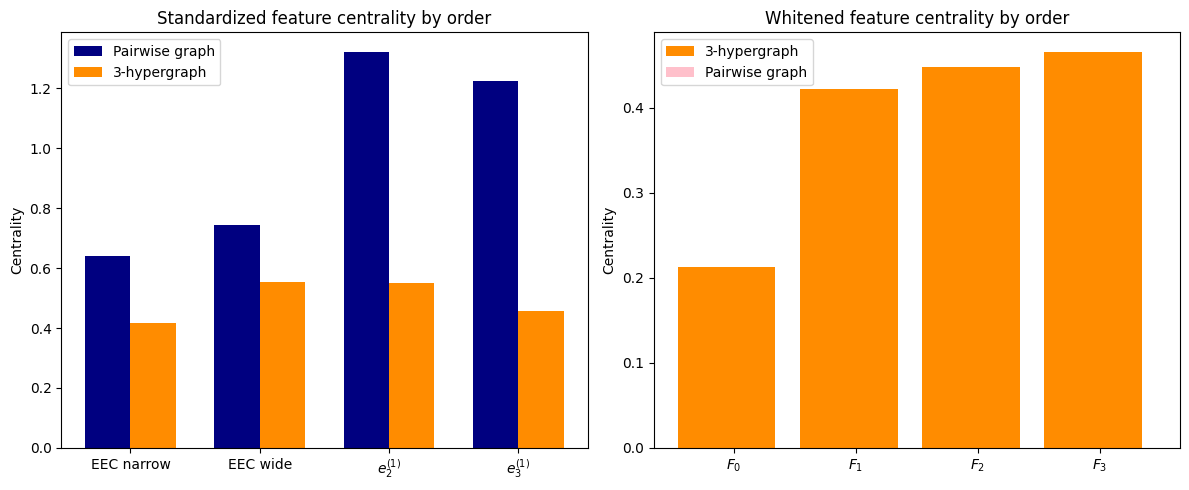

In [293]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(4)
width = 0.35
obs_names = ["EEC narrow", "EEC wide", r"$e_2^{(1)}$", r"$e_3^{(1)}$"]
# Left panel — standardized basis
axes[0].bar(x - width/2, Pair, width, label='Pairwise graph', color='navy')
axes[0].bar(x + width/2, Hyper, width, label='3-hypergraph', color='darkorange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(obs_names)
axes[0].set_ylabel("Centrality")
axes[0].set_title("Standardized feature centrality by order")
axes[0].legend()

F_names = [f"$F_{i}$" for i in range(4)]
axes[1].bar(x - width/6, I3_whitened, color='darkorange', label='3-hypergraph')
axes[1].bar(x + width/6, I2_whitened, color='pink', label='Pairwise graph')
axes[1].set_xticks(x)
axes[1].set_xticklabels(F_names)
axes[1].set_ylabel("Centrality")
axes[1].set_title("Whitened feature centrality by order")
axes[1].legend()

plt.tight_layout()
plt.savefig("figure3.png", dpi=150)
plt.show()

### Figure 4

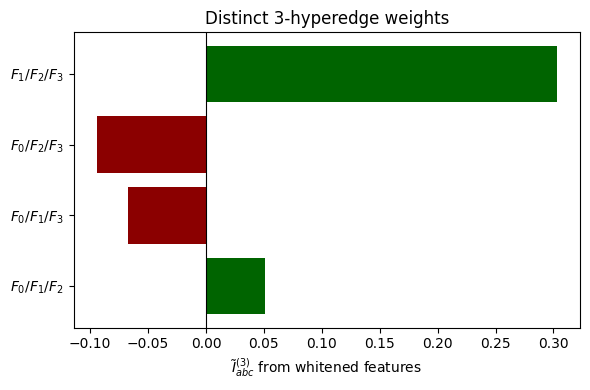

$F_0/F_1/F_2$: 0.050673
$F_0/F_1/F_3$: -0.067616
$F_0/F_2/F_3$: -0.094464
$F_1/F_2/F_3$: 0.303033


In [294]:
F0_F1_F2 = I3_whitened_basis[0,1,2]   # = hyperedge F0F1F2
F0_F1_F3 = I3_whitened_basis[0,1,3]   # = hyperedge F0F1F3
F0_F2_F3 = I3_whitened_basis[0,2,3]   # = hyperedge F0F2F3
F1_F2_F3 = I3_whitened_basis[1,2,3]   # = hyperedge F1F2F3

triplet_labels = triplet_labels = [
    r"$F_0/F_1/F_2$",
    r"$F_0/F_1/F_3$",
    r"$F_0/F_2/F_3$",
    r"$F_1/F_2/F_3$"
]
triplet_weights = [F0_F1_F2, F0_F1_F3, F0_F2_F3, F1_F2_F3]

colors = ['darkgreen' if w > 0 else 'darkred' for w in triplet_weights]

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(triplet_labels, triplet_weights, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(r"$\tilde{I}^{(3)}_{abc}$ from whitened features")
ax.set_title("Distinct 3-hyperedge weights")
plt.tight_layout()
plt.show()

for label, w in zip(triplet_labels, triplet_weights):
    print(f"{label}: {w:.6f}")